In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys


def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
sys.path.append(proj_root)

from opinion_dynamics.experiments.online_nonlinear import run_single_seed_experiment


In [3]:
# import time
# from opinion_dynamics.experiments.online import run_multi_seed_experiment_dynamics

# def timed_one(seed, dynamics):
#     t0 = time.time()
#     if dynamics == "laplacian":
#         df = run_multi_seed_experiment_dynamics(
#             seeds=[seed],
#             dynamics_model=dynamics,
#             B_campaign=1.0,
#             num_campaigns_total=5,
#             suppress_fit_logs=True,
#         )
#     elif dynamics == "coca":
#         df = run_multi_seed_experiment_dynamics(
#             seeds=[seed],
#             dynamics_model=dynamics,
#             B_campaign=1.0,
#             num_campaigns_total=5,
#             suppress_fit_logs=True,
#             fit_max_steps=10000,
#             fit_mae_stop=2e-3,
#             fit_batch_size=256,
#         )
#     dt = time.time() - t0

#     row = df.iloc[0].to_dict()
#     print(f"[{dynamics}] seed={seed} total_time={dt:.2f}s")

#     # Only print if those columns exist
#     if "time_online" in row:
#         print(
#             f"  time_online={row.get('time_online', float('nan')):.3f}s | "
#             f"time_fit_inner={row.get('time_fit_inner', float('nan')):.3f}s | "
#             f"time_step_inner={row.get('time_step_inner', float('nan')):.3f}s | "
#             f"fit_calls={row.get('fit_calls_inner', 'NA')} | "
#             f"step_calls={row.get('step_calls_inner', 'NA')}"
#         )

#     return df

# timed_one(0, "laplacian")
# timed_one(0, "coca")

In [ ]:
# =========================================================
# Multi-seed experiment (10 seeds) — collect metrics only
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd

from opinion_dynamics.experiments.online import run_multi_seed_experiment_dynamics

seeds = range(10)
B_campaign = 1.0
num_campaigns_total = 5

# Laplacian: keep "good" fit budget
df_lap = run_multi_seed_experiment_dynamics(
    seeds=seeds,
    dynamics_model="laplacian",
    B_campaign=B_campaign,
    num_campaigns_total=num_campaigns_total,
    suppress_fit_logs=True,

    # fit budget (laplacian)
    fit_max_steps=50_000,
    fit_mae_stop=1e-3,
    fit_batch_size=64,
    fit_check_every=200,

    timing=True,
    timing_print=False,
)

# COCA: tighter fit budget (much faster)
df_coca = run_multi_seed_experiment_dynamics(
    seeds=seeds,
    dynamics_model="coca",
    B_campaign=B_campaign,
    num_campaigns_total=num_campaigns_total,
    suppress_fit_logs=True,

    # tighter fit for COCA (because the Laplacian learner won't hit tiny mae anyway)
    fit_max_steps=5000,
    fit_mae_stop=1e-2,
    fit_batch_size=256,
    timing=True,
    timing_print=True,
)

df = pd.concat([df_lap, df_coca], axis=0).reset_index(drop=True)
display(df)

print("\n=== Aggregate by dynamics ===")
cols = ["v_L1_final","A_MAE_final","mean_gap_to_oracle_end","vx_gap_to_oracle_end","time_total","time_online","time_fit_inner"]
display(df.groupby("dynamics")[cols].describe().T)

# Simple comparison plot
plt.figure(figsize=(9,3))
for dyn in ["laplacian", "coca"]:
    sub = df[df["dynamics"] == dyn].sort_values("seed")
    plt.plot(sub["seed"], sub["A_MAE_final"], marker="o", label=f"{dyn}: A_MAE")
plt.xlabel("seed"); plt.ylabel("MAE(A_hat, A_true)")
plt.title("Adjacency MAE vs seed (laplacian vs coca)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(9,3))
for dyn in ["laplacian", "coca"]:
    sub = df[df["dynamics"] == dyn].sort_values("seed")
    plt.plot(sub["seed"], sub["v_L1_final"], marker="o", label=f"{dyn}: v_L1")
plt.xlabel("seed"); plt.ylabel("||v_hat - v_true||_1")
plt.title("Centrality error vs seed (laplacian vs coca)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

[coca] seed=0 total=18.36s online=18.35s oracle=0.00s noc=0.00s (make_env=0.001s) | inner_fit=18.35s/5 inner_step=0.0006s/5 | fit_budget: steps=5000 mae_stop=0.01 batch=256 check=200
[coca] seed=1 total=4.75s online=4.75s oracle=0.00s noc=0.00s (make_env=0.001s) | inner_fit=4.75s/5 inner_step=0.0006s/5 | fit_budget: steps=5000 mae_stop=0.01 batch=256 check=200


=== METRICS ===
seed: 6
dynamics: coca
N: 15
v_L1_final: 0.9361528823891808
A_Fro_final: 3.067204231016762
A_MAE_final: 0.10258931925505518
mean_oracle_end: 0.6015564721889041
mean_learn_end: 0.6043252587702228
mean_noc_end: 0.32825749086967093
mean_gap_to_oracle_end: 0.0027687865813187384
mean_err_avg: 0.00408178202545358
mean_err_max: 0.008416706189536605
vx_gap_to_oracle_end: 0.06130801654333495
vx_err_avg: 0.029829672033852627
vx_err_max: 0.06130801654333495

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.053195071273723
edges: 38
sink_sizes: [11]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.999999943189323
row_sum_mean: 1.0000000113310914
row_sum_max: 1.0000001036096364
asym: 0.5062301201793663
edges: 210
sink_sizes: [15]
has_singleton_sink: False


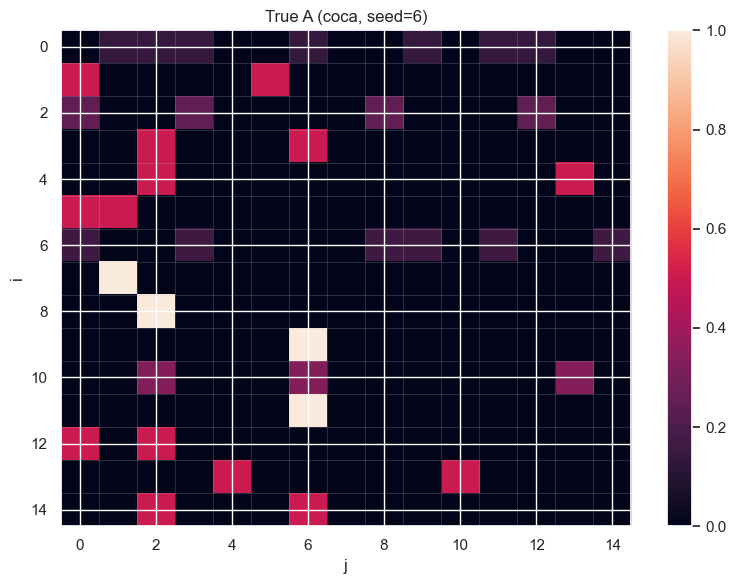

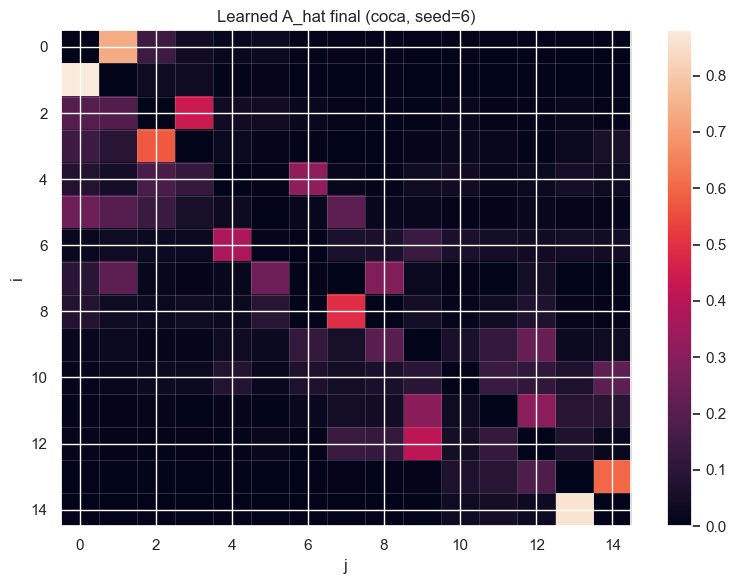

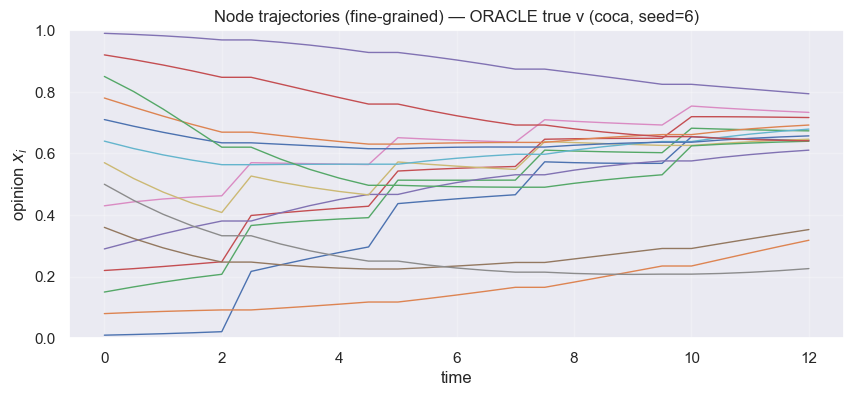

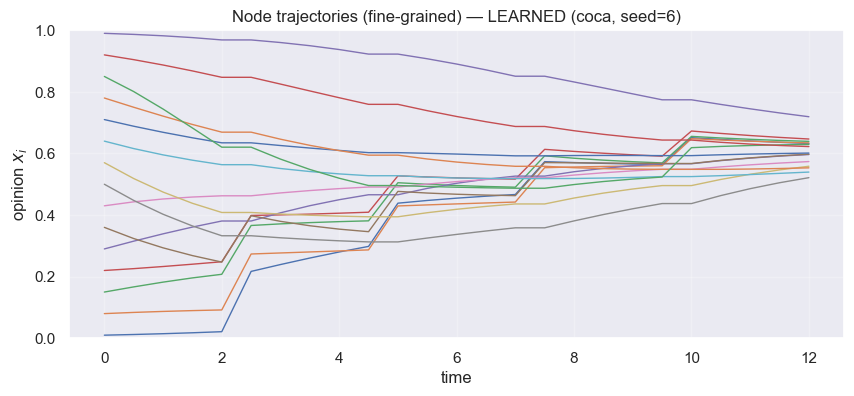


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.9361528823891808


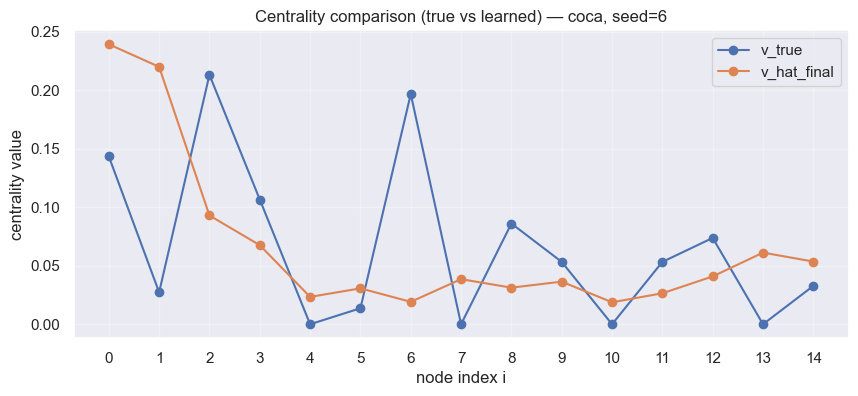

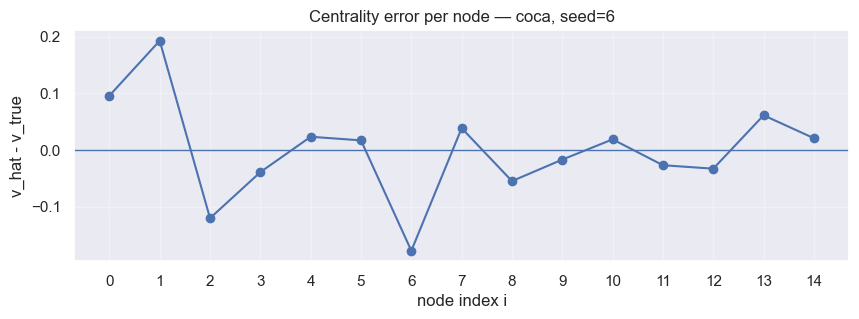

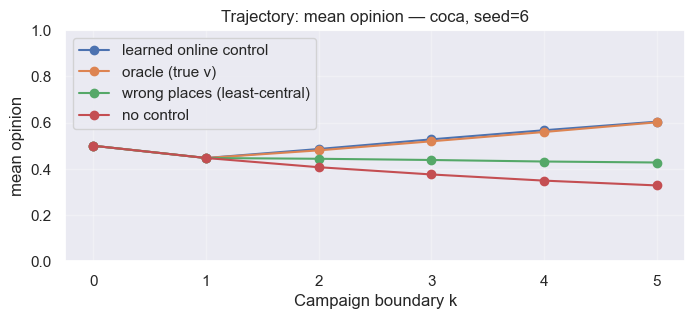


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.0
learned states[1] vs nocontrol states[1] L_inf: 0.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate,
)
from opinion_dynamics.experiments.metrics import graph_sanity
from opinion_dynamics.experiments.rollouts import rollout_with_v_intermediate


# =========================================================
# Settings
# =========================================================
SEED_TO_PLOT = 6

DYNAMICS = "coca"   # or "laplacian"

FIT_KW = dict(
    fit_max_steps=800 if DYNAMICS == "coca" else 50_000,
    fit_mae_stop=1e-2 if DYNAMICS == "coca" else 1e-3,
    fit_batch_size=512 if DYNAMICS == "coca" else 64,
    fit_check_every=200,
)

metrics, art = run_single_seed_experiment(
    seed=SEED_TO_PLOT,
    dynamics_model=DYNAMICS,
    B_campaign=B_campaign,
    num_campaigns_total=num_campaigns_total,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    update_A_each_campaign=True,
    suppress_fit_logs=True,
    return_artifacts=True,
    **FIT_KW,
)

print("=== METRICS ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

env_learn = art["env"]

# =========================================================
# 2) Pull ground-truth + learned-final
# =========================================================
A_true = np.asarray(art["A_true"], dtype=float)
v_true = np.asarray(art["v_true"], dtype=float)

A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

states_learn = np.asarray(art["states_learn"], dtype=float)  # (K+1, N)
x0 = np.asarray(art["x0"], dtype=float)
N = states_learn.shape[1]
K_total = states_learn.shape[0] - 1

# =========================================================
# 3) Build a fresh env for rollouts (same graph/params)
# =========================================================
EnvCls = env_learn.__class__
env_base = EnvCls(**art["env_template_kwargs"])

# =========================================================
# 4) GRAPH SANITY (true vs learned-final)
# =========================================================
print("\n=== GRAPH SANITY (TRUE) ===")
for k, v in graph_sanity(A_true).items():
    print(f"{k}: {v}")

print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
for k, v in graph_sanity(A_hat_final).items():
    print(f"{k}: {v}")

# =========================================================
# 5) Heatmaps (muted grid)
# =========================================================
show_matrix_with_cell_grid(A_true,      title=f"True A ({DYNAMICS}, seed={SEED_TO_PLOT})", grid_alpha=0.25, grid_lw=0.6)
show_matrix_with_cell_grid(A_hat_final, title=f"Learned A_hat final ({DYNAMICS}, seed={SEED_TO_PLOT})", grid_alpha=0.25, grid_lw=0.6)

# =========================================================
# 6) Fine-grained trajectories for LEARNED run (actual)
# =========================================================
inter_list = art["intermediate_states_list"]
time_list  = art["intermediate_times_list"]

valid_pairs = [(xs, ts) for xs, ts in zip(inter_list, time_list) if xs is not None and ts is not None]
if not valid_pairs:
    raise RuntimeError("No intermediate trajectories found. Ensure env.step returns info['intermediate_states'].")

dt = float(getattr(env_learn, "t_s", 1.0))
X_le, T_le = concat_intermediate(inter_list, time_list, dt=dt)

# =========================================================
# 7) Oracle + no-control rollouts WITH intermediate (fresh env, same x0)
# =========================================================
or_out = rollout_with_v_intermediate(env_base, x0, K_total, B_campaign, v_true, zero_first_campaign=True)
nc_out = rollout_with_v_intermediate(env_base, x0, K_total, B_campaign, None,   zero_first_campaign=True)

X_or, T_or = concat_intermediate(or_out["intermediate_states_list"], or_out["intermediate_times_list"], dt=dt)

# =========================================================
# 7.5) "Wrong places" control: allocate budget to least-central nodes
# =========================================================
# We want centrality_based_continuous_control (which sorts by v * deviation desc)
# to pick nodes with *small v_true*. Make v_anti: big where v_true is small.
order = np.argsort(v_true)             # ascending: least central first
ranks = np.empty_like(order, dtype=float)
ranks[order] = np.arange(1, len(v_true) + 1)  # 1..N (most central gets largest rank)
v_anti = (1.0 / ranks)                 # least-central -> 1.0, most-central -> 1/N
v_anti = v_anti / v_anti.sum()

# Rollout with "anti-centrality" oracle (still uses same control allocation rule)
anti_out = rollout_with_v_intermediate(
    env_base, x0, K_total, B_campaign, v_anti, zero_first_campaign=True
)

# =========================================================
# 8) Impulse-style plots
# =========================================================
plot_impulse_node_trajectories(X_or, T_or, title=f"Node trajectories (fine-grained) — ORACLE true v ({DYNAMICS}, seed={SEED_TO_PLOT})")
plot_impulse_node_trajectories(X_le, T_le, title=f"Node trajectories (fine-grained) — LEARNED ({DYNAMICS}, seed={SEED_TO_PLOT})")

# =========================================================
# 9) Centrality comparison (NO sorting)
# =========================================================
print("\n=== CENTRALITY COMPARISON (by node index) ===")
print("L1(v_hat_final - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))

idx = np.arange(N)
diff = v_hat_final - v_true

plt.figure(figsize=(10, 4))
plt.plot(idx, v_true, marker="o", label="v_true")
plt.plot(idx, v_hat_final, marker="o", label="v_hat_final")
plt.xlabel("node index i")
plt.ylabel("centrality value")
plt.title(f"Centrality comparison (true vs learned) — {DYNAMICS}, seed={SEED_TO_PLOT}")
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.axhline(0.0, linewidth=1)
plt.plot(idx, diff, marker="o")
plt.xlabel("node index i")
plt.ylabel("v_hat - v_true")
plt.title(f"Centrality error per node — {DYNAMICS}, seed={SEED_TO_PLOT}")
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 10) Mean opinion plot (campaign boundaries) + wrong-places baseline
# =========================================================
states_oracle = np.asarray(or_out["states"], dtype=float)
states_noc    = np.asarray(nc_out["states"], dtype=float)
states_anti   = np.asarray(anti_out["states"], dtype=float)

mean_learn = states_learn.mean(axis=1)
mean_or    = states_oracle.mean(axis=1)
mean_nc    = states_noc.mean(axis=1)
mean_anti  = states_anti.mean(axis=1)

plt.figure(figsize=(8, 3))
plt.plot(mean_learn, marker="o", label="learned online control")
plt.plot(mean_or,    marker="o", label="oracle (true v)")
plt.plot(mean_anti,  marker="o", label="wrong places (least-central)")
plt.plot(mean_nc,    marker="o", label="no control")
plt.xlabel("Campaign boundary k")
plt.ylabel("mean opinion")
plt.title(f"Trajectory: mean opinion — {DYNAMICS}, seed={SEED_TO_PLOT}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)
plt.show()

print("\n=== CAMPAIGN-0 OVERLAP CHECK ===")
print("learned states[1] vs oracle states[1] L_inf:", float(np.max(np.abs(states_learn[1] - states_oracle[1]))))
print("learned states[1] vs nocontrol states[1] L_inf:", float(np.max(np.abs(states_learn[1] - states_noc[1]))))